# Thermal-relaxation asymptote — experimental calibration

In [DZNE_VS_PEC_mitiq.ipynb](DZNE_VS_PEC_mitiq.ipynb) §6.3 the thermal `NoiseSpec` is built with `asymptote=0.7`, flagged as *rough empirical value*. That asymptote is consumed by `ExpFactory(asymptote=...)` and `AdaExpFactory(asymptote=...)`: a wrong value forces the exponential ansatz `a + b·exp(-c·λ)` through the wrong fixed point and produces the aberrant ExpFactory result seen earlier (ExpFactory blew up to ~3006 under thermal noise).

**Approach.** The asymptote is, by definition, `lim_{λ→∞} ⟨P(|00⟩)⟩` under the per-gate noise channel applied to the folded benchmark `U·U⁻¹·|00⟩`. We sweep `λ` (via `fold_global`) over a wide range up to λ=100 (≈3000 gates), average across 8 random Clifford seeds, then fit `a + b·exp(-c·λ)` and read `a`.

**Sanity check.** Same procedure on the depolarizing model — analytical asymptote is 0.25 (state → I/4). If the fit misses by more than 0.02, the methodology is wrong before we trust the thermal number.

## 1. Setup

Reuses verbatim the building blocks from `DZNE_VS_PEC_mitiq.ipynb`: `make_benchmark_circuit`, `kraus_thermal_1q`, noise-model construction.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, kraus_error
from qiskit.circuit.random import random_clifford_circuit

from mitiq.zne.scaling import fold_global

# Same constants as DZNE_VS_PEC_mitiq.ipynb
N_QUBITS, DEPTH = 2, 10
BASIS_GATES   = ['h', 'rz', 'sx', 'x', 'cx', 'id', 'sxdg']
_GATES_1Q     = ['h', 'rz', 'sx', 'x', 'sxdg', 'id']
_GATES_2Q     = ['cx']

# Sweep parameters
LAMBDAS = [1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0, 75.0, 100.0]
N_SEEDS = 8
SHOTS   = 10_000
SEEDS   = list(range(N_SEEDS))

# Thermal channel parameters — same as DZNE_VS_PEC_mitiq.ipynb §6.3
GAMMA_TH_AD_1Q = 0.005; GAMMA_TH_PD_1Q = 0.005
GAMMA_TH_AD_2Q = 0.025; GAMMA_TH_PD_2Q = 0.025

# Depolarizing channel — same as §1
P1_DEPOL = 0.01
P2_DEPOL = 0.05

CURRENT_ASYMPTOTE_TH = 0.7   # the value we want to revisit
ANALYTICAL_ASYMPTOTE_DEPOL = 0.25

print(f"Sweep: {len(LAMBDAS)} lambdas × {N_SEEDS} seeds × {SHOTS} shots/circuit")

Sweep: 13 lambdas × 8 seeds × 10000 shots/circuit


In [2]:
def make_benchmark_circuit(seed: int):
    rc = random_clifford_circuit(num_qubits=N_QUBITS, num_gates=DEPTH, seed=seed)
    circ = rc.compose(rc.inverse())
    return transpile(circ, basis_gates=BASIS_GATES, optimization_level=0)


def kraus_thermal_1q(gamma_ad: float, gamma_pd: float):
    """Composite AD(γ_ad) ∘ PD(γ_pd) per qubit. K_ij = A_i · P_j  =>  4 Kraus ops."""
    g, l = gamma_ad, gamma_pd
    return [
        np.array([[1, 0], [0, np.sqrt((1-g)*(1-l))]], dtype=complex),
        np.array([[0, 0], [0, np.sqrt(l*(1-g))]],     dtype=complex),
        np.array([[0, np.sqrt(g*(1-l))], [0, 0]],     dtype=complex),
        np.array([[0, np.sqrt(g*l)],     [0, 0]],     dtype=complex),
    ]


def build_thermal_noise_model():
    """Same as SPEC_TH.build_noise_model() in DZNE_VS_PEC_mitiq.ipynb §6.3."""
    k1 = kraus_thermal_1q(GAMMA_TH_AD_1Q, GAMMA_TH_PD_1Q)
    k2q_per_qubit = kraus_thermal_1q(GAMMA_TH_AD_2Q, GAMMA_TH_PD_2Q)
    err_1q = kraus_error(k1)
    err_2q_local = kraus_error(k2q_per_qubit)
    err_2q = err_2q_local.tensor(err_2q_local)
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(err_1q, _GATES_1Q)
    nm.add_all_qubit_quantum_error(err_2q, _GATES_2Q)
    return nm


def build_depolarizing_noise_model():
    """Same as DZNE_VS_PEC_mitiq.ipynb §1."""
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(P1_DEPOL, 1), _GATES_1Q)
    nm.add_all_qubit_quantum_error(depolarizing_error(P2_DEPOL, 2), _GATES_2Q)
    return nm


def make_executor(backend, shots=SHOTS):
    def executor(circuit) -> float:
        qc = circuit.copy()
        qc.measure_all()
        counts = backend.run(qc, shots=shots).result().get_counts()
        return counts.get('0' * circuit.num_qubits, 0) / shots
    return executor

## 2. λ sweep — generic routine

For each `(seed, λ)`: fold the benchmark circuit with `fold_global(scale_factor=λ)`, run noisy executor, record `P(|00⟩)`. We then average across seeds to remove circuit-to-circuit fluctuations.

In [3]:
def sweep_lambda(noise_model, label: str):
    """Return (mean_over_seeds, std_over_seeds) arrays of shape (len(LAMBDAS),)."""
    backend  = AerSimulator(noise_model=noise_model)
    executor = make_executor(backend)
    results  = np.zeros((N_SEEDS, len(LAMBDAS)))
    print(f"=== {label} ===")
    for j, lam in enumerate(LAMBDAS):
        for i, s in enumerate(SEEDS):
            circ   = make_benchmark_circuit(s)
            folded = fold_global(circ, scale_factor=lam)
            results[i, j] = executor(folded)
        n_gates = sum(fold_global(make_benchmark_circuit(0), scale_factor=lam).count_ops().values())
        print(f"  lambda={lam:>6.1f}   n_gates={n_gates:>5d}   mean P(|00>)={results[:, j].mean():.4f}   std={results[:, j].std():.4f}")
    return results.mean(axis=0), results.std(axis=0)

## 3. Sanity check — depolarizing channel

Analytical asymptote = 0.25 (state → I/4 as noise grows). The fit must hit this value within shot noise (≈ ±0.02) for the methodology to be trustworthy.

In [4]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mean_depol, std_depol = sweep_lambda(build_depolarizing_noise_model(), 'Depolarizing')

=== Depolarizing ===
  lambda=   1.0   n_gates=   44   mean P(|00>)=0.5352   std=0.0709
  lambda=   1.5   n_gates=   66   mean P(|00>)=0.4283   std=0.0731
  lambda=   2.0   n_gates=   88   mean P(|00>)=0.3604   std=0.0551
  lambda=   3.0   n_gates=  132   mean P(|00>)=0.2979   std=0.0365
  lambda=   5.0   n_gates=  220   mean P(|00>)=0.2572   std=0.0111
  lambda=   7.0   n_gates=  308   mean P(|00>)=0.2537   std=0.0033
  lambda=  10.0   n_gates=  440   mean P(|00>)=0.2522   std=0.0035
  lambda=  15.0   n_gates=  660   mean P(|00>)=0.2499   std=0.0032
  lambda=  20.0   n_gates=  880   mean P(|00>)=0.2505   std=0.0055
  lambda=  30.0   n_gates= 1320   mean P(|00>)=0.2493   std=0.0029
  lambda=  50.0   n_gates= 2200   mean P(|00>)=0.2494   std=0.0042
  lambda=  75.0   n_gates= 3300   mean P(|00>)=0.2505   std=0.0047
  lambda= 100.0   n_gates= 4400   mean P(|00>)=0.2518   std=0.0042


## 4. Target — thermal-relaxation channel

In [5]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mean_th, std_th = sweep_lambda(build_thermal_noise_model(), 'ThermalRelaxation')

=== ThermalRelaxation ===
  lambda=   1.0   n_gates=   44   mean P(|00>)=0.7158   std=0.0870
  lambda=   1.5   n_gates=   66   mean P(|00>)=0.6607   std=0.1040
  lambda=   2.0   n_gates=   88   mean P(|00>)=0.5640   std=0.1179
  lambda=   3.0   n_gates=  132   mean P(|00>)=0.4862   std=0.1219
  lambda=   5.0   n_gates=  220   mean P(|00>)=0.4145   std=0.1220
  lambda=   7.0   n_gates=  308   mean P(|00>)=0.3940   std=0.1275
  lambda=  10.0   n_gates=  440   mean P(|00>)=0.3799   std=0.1304
  lambda=  15.0   n_gates=  660   mean P(|00>)=0.3794   std=0.1253
  lambda=  20.0   n_gates=  880   mean P(|00>)=0.3743   std=0.1281
  lambda=  30.0   n_gates= 1320   mean P(|00>)=0.3764   std=0.1292
  lambda=  50.0   n_gates= 2200   mean P(|00>)=0.3761   std=0.1298
  lambda=  75.0   n_gates= 3300   mean P(|00>)=0.3779   std=0.1280
  lambda= 100.0   n_gates= 4400   mean P(|00>)=0.3758   std=0.1287


## 5. Exponential fit

Model: `f(λ) = a + b·exp(-c·λ)`. Initial guess: `a` = value at λ_max, `b` = value at λ=1 minus `a`, `c` = 0.05.

In [6]:
def exp_model(lam, a, b, c):
    return a + b * np.exp(-c * lam)


def fit_asymptote(lambdas, means, label: str):
    lambdas = np.asarray(lambdas, dtype=float)
    p0 = [means[-1], means[0] - means[-1], 0.05]
    try:
        popt, pcov = curve_fit(exp_model, lambdas, means, p0=p0, maxfev=20_000)
        perr = np.sqrt(np.diag(pcov))
        a_fit, b_fit, c_fit = popt
        a_err = perr[0]
        print(f"[{label}] fit:  a = {a_fit:.4f} ± {a_err:.4f},  b = {b_fit:+.4f},  c = {c_fit:.4f}")
    except RuntimeError as e:
        print(f"[{label}] fit FAILED ({e}). Falling back to value at largest lambda.")
        a_fit, b_fit, c_fit, a_err = means[-1], None, None, std_depol[-1] / np.sqrt(N_SEEDS)
    print(f"[{label}] raw P(|00>) at lambda={lambdas[-1]}: {means[-1]:.4f}")
    return a_fit, b_fit, c_fit


a_depol, b_depol, c_depol = fit_asymptote(LAMBDAS, mean_depol, 'Depolarizing')
a_th,    b_th,    c_th    = fit_asymptote(LAMBDAS, mean_th,    'ThermalRelaxation')

depol_drift = abs(a_depol - ANALYTICAL_ASYMPTOTE_DEPOL)
print()
print(f"Depolarizing sanity:   fitted={a_depol:.4f}   analytical=0.25   |diff|={depol_drift:.4f}")
if depol_drift > 0.02:
    print("  WARNING: methodology off by more than 0.02 on the depol sanity check.")
else:
    print("  OK: methodology reproduces the analytical value within shot noise.")

[Depolarizing] fit:  a = 0.2509 ± 0.0006,  b = +0.7213,  c = 0.9331
[Depolarizing] raw P(|00>) at lambda=100.0: 0.2518
[ThermalRelaxation] fit:  a = 0.3771 ± 0.0031,  b = +0.6075,  c = 0.5598
[ThermalRelaxation] raw P(|00>) at lambda=100.0: 0.3758

Depolarizing sanity:   fitted=0.2509   analytical=0.25   |diff|=0.0009
  OK: methodology reproduces the analytical value within shot noise.


## 6. Plot

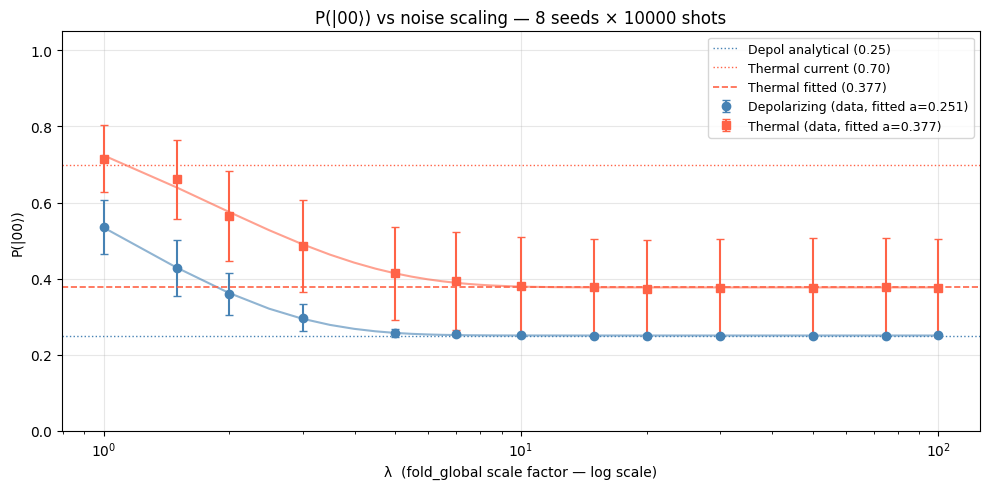

In [7]:
lam_grid = np.linspace(LAMBDAS[0], LAMBDAS[-1], 200)
fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(LAMBDAS, mean_depol, yerr=std_depol, fmt='o', color='steelblue',
            label=f'Depolarizing (data, fitted a={a_depol:.3f})', capsize=3)
ax.plot(lam_grid, exp_model(lam_grid, a_depol, b_depol, c_depol), '-', color='steelblue', alpha=0.6)
ax.axhline(ANALYTICAL_ASYMPTOTE_DEPOL, color='steelblue', ls=':', lw=1, label='Depol analytical (0.25)')

ax.errorbar(LAMBDAS, mean_th, yerr=std_th, fmt='s', color='tomato',
            label=f'Thermal (data, fitted a={a_th:.3f})', capsize=3)
ax.plot(lam_grid, exp_model(lam_grid, a_th, b_th, c_th), '-', color='tomato', alpha=0.6)
ax.axhline(CURRENT_ASYMPTOTE_TH, color='tomato', ls=':', lw=1, label=f'Thermal current (0.70)')
ax.axhline(a_th, color='tomato', ls='--', lw=1.2, label=f'Thermal fitted ({a_th:.3f})')

ax.set_xscale('log')
ax.set_xlabel('λ  (fold_global scale factor — log scale)')
ax.set_ylabel('P(|00⟩)')
ax.set_title(f'P(|00⟩) vs noise scaling — {N_SEEDS} seeds × {SHOTS} shots')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Recommendation

In [8]:
print('=' * 60)
print('CALIBRATION RESULT')
print('=' * 60)
print(f'Current   SPEC_TH.asymptote : {CURRENT_ASYMPTOTE_TH}')
print(f'Fitted    SPEC_TH.asymptote : {a_th:.4f}')
print(f'Raw mean P(|00>) at λ=100  : {mean_th[-1]:.4f}')
print()
print(f'Delta vs current: {a_th - CURRENT_ASYMPTOTE_TH:+.4f}')
print()
print('--> Update DZNE_VS_PEC_mitiq.ipynb §6.3 cell 46:')
print(f'      SPEC_TH = NoiseSpec(... asymptote={a_th:.3f} ...)')
print()
print('Then re-run §6.3 / §6.4 and confirm ExpFactory no longer diverges.')

CALIBRATION RESULT
Current   SPEC_TH.asymptote : 0.7
Fitted    SPEC_TH.asymptote : 0.3771
Raw mean P(|00>) at λ=100  : 0.3758

Delta vs current: -0.3229

--> Update DZNE_VS_PEC_mitiq.ipynb §6.3 cell 46:
      SPEC_TH = NoiseSpec(... asymptote=0.377 ...)

Then re-run §6.3 / §6.4 and confirm ExpFactory no longer diverges.
